In [1]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
from scipy.stats import linregress

In [2]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("mutual_fund.db")

files = {
    "fund_master": "data/raw/01_fund_master.csv",
    "nav_history": "data/raw/02_nav_history.csv",
    "benchmark_indices": "data/raw/10_benchmark_indices.csv"
}

for table, file in files.items():
    df = pd.read_csv(file)
    df.to_sql(table, conn, if_exists="replace", index=False)

conn.commit()
conn.close()

print("Database created successfully!")

Database created successfully!


In [3]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("mutual_fund.db")

# Load tables
fund_df = pd.read_sql("SELECT * FROM fund_master", conn)
nav_df = pd.read_sql("SELECT * FROM nav_history", conn)
benchmark_df = pd.read_sql("SELECT * FROM benchmark_indices", conn)

print("Fund Master Shape:", fund_df.shape)
print("NAV History Shape:", nav_df.shape)
print("Benchmark Shape:", benchmark_df.shape)

display(fund_df.head())
display(nav_df.head())
display(benchmark_df.head())

Fund Master Shape: (40, 15)
NAV History Shape: (46000, 3)
Benchmark Shape: (8050, 3)


,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [4]:
# Calculate Daily Returns

nav_df['date'] = pd.to_datetime(nav_df['date'])
nav_df = nav_df.sort_values(['amfi_code', 'date'])

nav_df['daily_return'] = nav_df.groupby('amfi_code')['nav'].pct_change()

nav_df.head()

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210


In [5]:
nav_df[['amfi_code','date','nav','daily_return']].head(10)

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210
5755,100016,2022-01-10,510.7136,-0.008639
5756,100016,2022-01-11,513.5542,0.005562
5757,100016,2022-01-12,512.3195,-0.002404
5758,100016,2022-01-13,510.2445,-0.004050
5759,100016,2022-01-14,514.3636,0.008073


In [6]:
import numpy as np

cagr_list = []

for code, group in nav_df.groupby("amfi_code"):
    group = group.sort_values("date")

    start_nav = group.iloc[0]["nav"]
    end_nav = group.iloc[-1]["nav"]

    years = (group.iloc[-1]["date"] - group.iloc[0]["date"]).days / 365.25

    if years > 0:
        cagr = ((end_nav / start_nav) ** (1 / years)) - 1
    else:
        cagr = np.nan

    cagr_list.append({
        "amfi_code": code,
        "CAGR": cagr
    })

cagr_df = pd.DataFrame(cagr_list)

cagr_df.head()

,amfi_code,CAGR
0,100016,0.026371
1,100025,0.044582
2,100033,0.301232
3,101206,0.235384
4,101207,0.079388


In [7]:
risk_free_rate = 0.065

sharpe_list = []

for code, group in nav_df.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    if len(returns) > 1:

        sharpe = ((returns.mean()*252) - risk_free_rate) / (returns.std()*np.sqrt(252))

    else:

        sharpe = np.nan

    sharpe_list.append({
        "amfi_code": code,
        "Sharpe": sharpe
    })

sharpe_df = pd.DataFrame(sharpe_list)

sharpe_df.head()

,amfi_code,Sharpe
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [8]:
sortino_list = []

for code, group in nav_df.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    downside = returns[returns < 0]

    if len(downside) > 1:

        downside_std = downside.std() * np.sqrt(252)

        sortino = ((returns.mean()*252) - risk_free_rate) / downside_std

    else:

        sortino = np.nan

    sortino_list.append({
        "amfi_code": code,
        "Sortino": sortino
    })

sortino_df = pd.DataFrame(sortino_list)

sortino_df.head()

,amfi_code,Sortino
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


In [9]:
drawdown_list = []

for code, group in nav_df.groupby("amfi_code"):

    group = group.sort_values("date")

    running_max = group["nav"].cummax()

    drawdown = (group["nav"] - running_max) / running_max

    drawdown_list.append({
        "amfi_code": code,
        "Max_Drawdown": drawdown.min()
    })

drawdown_df = pd.DataFrame(drawdown_list)

drawdown_df.head()

,amfi_code,Max_Drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [10]:
score_df = cagr_df.merge(sharpe_df,on="amfi_code")
score_df = score_df.merge(sortino_df,on="amfi_code")
score_df = score_df.merge(drawdown_df,on="amfi_code")

score_df["Score"] = (
    score_df["CAGR"].rank(pct=True)*40 +
    score_df["Sharpe"].rank(pct=True)*30 +
    score_df["Sortino"].rank(pct=True)*20 +
    (-score_df["Max_Drawdown"]).rank(pct=True)*10
)

score_df = score_df.sort_values("Score",ascending=False)

score_df.head(10)

,amfi_code,CAGR,Sharpe,Sortino,Max_Drawdown,Score
25,120505,0.328274,1.180101,2.029353,-0.181885,91.25
36,148569,0.319495,1.234930,2.146914,-0.163967,89.75
34,148567,0.309741,1.448291,2.385644,-0.112657,88.00
30,120843,0.309075,1.306744,2.364320,-0.129740,87.00
21,119598,0.324235,0.945308,1.675317,-0.287060,82.75
38,149323,0.295811,1.132122,1.875101,-0.172481,82.25
39,149324,0.322874,0.949796,1.619793,-0.311719,81.75
19,119551,0.258047,1.208267,2.140267,-0.150124,81.50
2,100033,0.301232,1.093699,1.829134,-0.162172,81.00
9,118632,0.240495,1.081659,1.850133,-0.174141,77.50


In [11]:
score_df.to_csv("fund_scorecard.csv",index=False)

print("fund_scorecard.csv saved successfully.")

fund_scorecard.csv saved successfully.


In [12]:
score_df.head(5)

,amfi_code,CAGR,Sharpe,Sortino,Max_Drawdown,Score
25,120505,0.328274,1.180101,2.029353,-0.181885,91.25
36,148569,0.319495,1.234930,2.146914,-0.163967,89.75
34,148567,0.309741,1.448291,2.385644,-0.112657,88.00
30,120843,0.309075,1.306744,2.364320,-0.129740,87.00
21,119598,0.324235,0.945308,1.675317,-0.287060,82.75


In [13]:
alpha_beta_list = []

benchmark = benchmark_df.copy()
benchmark["benchmark_return"] = benchmark["close_value"].pct_change()

for code, group in nav_df.groupby("amfi_code"):

    fund = group.copy()
    fund["fund_return"] = fund["daily_return"]

    merged = pd.merge(
        fund,
        benchmark,
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    if len(merged) > 20:

        beta, alpha, r, p, stderr = linregress(
            merged["benchmark_return"],
            merged["fund_return"]
        )

        alpha = alpha * 252

    else:

        alpha = np.nan
        beta = np.nan

    alpha_beta_list.append({
        "amfi_code": code,
        "Alpha": alpha,
        "Beta": beta
    })

alpha_beta_df = pd.DataFrame(alpha_beta_list)

alpha_beta_df.head()

ValueError: You are trying to merge on datetime64[us] and str columns for key 'date'. If you wish to proceed you should use pd.concat

In [14]:
import pandas as pd
import numpy as np
from scipy.stats import linregress

# Make sure dates are datetime
nav_df["date"] = pd.to_datetime(nav_df["date"])
benchmark_df["date"] = pd.to_datetime(benchmark_df["date"])

# Benchmark daily returns
benchmark = benchmark_df.copy()
benchmark["benchmark_return"] = benchmark["close_value"].pct_change()

alpha_beta_list = []

# Calculate Alpha & Beta
for code, group in nav_df.groupby("amfi_code"):

    fund = group.copy()
    fund["date"] = pd.to_datetime(fund["date"])

    merged = pd.merge(
        fund,
        benchmark,
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    if len(merged) > 20:

        beta, alpha, r_value, p_value, std_err = linregress(
            merged["benchmark_return"],
            merged["daily_return"]
        )

        alpha = alpha * 252

    else:

        alpha = np.nan
        beta = np.nan

    alpha_beta_list.append({
        "amfi_code": code,
        "Alpha": alpha,
        "Beta": beta
    })

alpha_beta_df = pd.DataFrame(alpha_beta_list)

# Display first 5 rows
alpha_beta_df.head()

,amfi_code,Alpha,Beta
0,100016,0.035008,0.004843
1,100025,0.043330,-0.003422
2,100033,0.268752,0.024097
3,101206,0.214656,-0.000067
4,101207,0.110250,-0.023588


In [15]:
alpha_beta_df.to_csv("alpha_beta.csv", index=False)

print("alpha_beta.csv saved successfully!")

alpha_beta.csv saved successfully!


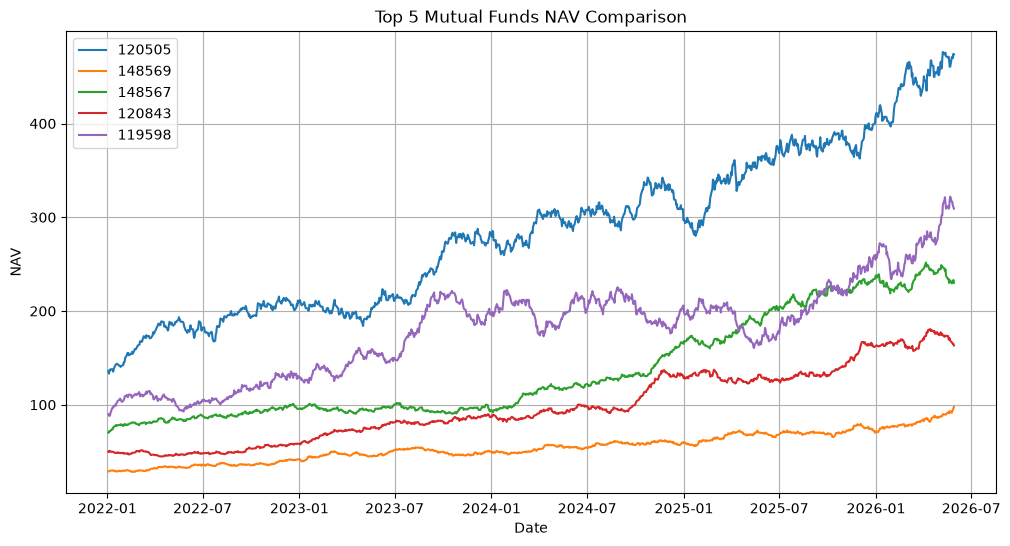

benchmark_comparison_chart.png saved successfully!


In [16]:
import matplotlib.pyplot as plt

# Top 5 funds based on score
top5 = score_df.sort_values("Score", ascending=False).head(5)["amfi_code"]

plt.figure(figsize=(12,6))

for code in top5:
    fund = nav_df[nav_df["amfi_code"] == code]
    plt.plot(fund["date"], fund["nav"], label=str(code))

plt.title("Top 5 Mutual Funds NAV Comparison")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.legend()
plt.grid(True)

plt.savefig("benchmark_comparison_chart.png")

plt.show()

print("benchmark_comparison_chart.png saved successfully!")

In [17]:
import os

files = [
    "fund_scorecard.csv",
    "alpha_beta.csv",
    "benchmark_comparison_chart.png"
]

for f in files:
    if os.path.exists(f):
        print("✅", f, "Found")
    else:
        print("❌", f, "Not Found")

✅ fund_scorecard.csv Found
✅ alpha_beta.csv Found
✅ benchmark_comparison_chart.png Found


In [18]:
print("Fund Performance Analytics Completed Successfully!")

Fund Performance Analytics Completed Successfully!


In [19]:
import os

for file in [
    "fund_scorecard.csv",
    "alpha_beta.csv",
    "benchmark_comparison_chart.png"
]:
    print(file, ":", os.path.getsize(file), "bytes")

fund_scorecard.csv : 3752 bytes
alpha_beta.csv : 1999 bytes
benchmark_comparison_chart.png : 109525 bytes
